## Spread Rolling

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("btc_project_train.csv")
data = data.dropna(subset=["Close"]).reset_index(drop=True)
data["Datetime"] = pd.to_datetime(data["Datetime"])

precio = data["Close"]

print("Rango de fechas:", data["Datetime"].min(), "→", data["Datetime"].max())
print("N° de observaciones:", len(precio))
print("Precio medio:", precio.mean())

Rango de fechas: 2022-06-01 00:00:00 → 2023-12-31 00:00:00
N° de observaciones: 162705
Precio medio: 25659.050231847934


In [4]:
def roll_spread(price):
    delta = price.diff().dropna()
    cov = delta.cov(delta.shift(1))
    var = delta.var()
    if cov < 0:
        s = 2 * np.sqrt(-cov)
        sigma_u2 = var + 2 * cov
    else:
        s, sigma_u2 = np.nan, np.nan
    return s, sigma_u2, cov

s, sigma_u2, cov = roll_spread(precio)
print("Cov(dPt, dPt-1) =", cov)
print("Var(dPt)        =", precio.diff().var())
print("s     =", s)
print("sigma_u^2 =", sigma_u2)

Cov(dPt, dPt-1) = 64.36601627014599
Var(dPt)        = 1247.188140869822
s     = nan
sigma_u^2 = nan


In [ ]:
N = 20
delta = precio.diff()
roll_cov = delta.rolling(window=N).cov(delta.shift(1))

validas = roll_cov.dropna()
frac_definida = (validas < 0).mean()
frac_indefinida = (validas >= 0).mean()

print("Ventanas con estimador definido (Cov<0):", frac_definida)
print("Ventanas con estimador indefinido (Cov>=0):", frac_indefinida)

Ventanas con estimador definido (Cov<0): 0.46239335152811584
Ventanas con estimador indefinido (Cov>=0): 0.5376066484718841


In [6]:
def infer_trade_direction(price):
    delta = price.diff()
    q = np.sign(delta).replace(0, np.nan).ffill()
    q = q.fillna(1.0)  # primera observación sin dirección previa
    return q

def roll_efficient_price(price, s, q):
    return price - (s / 2.0) * q

In [7]:
seg = data.iloc[500:1000].reset_index(drop=True)
p = seg["Close"]
s, sigma_u2, cov = roll_spread(p)
q = infer_trade_direction(p)
m = roll_efficient_price(p, s, q)

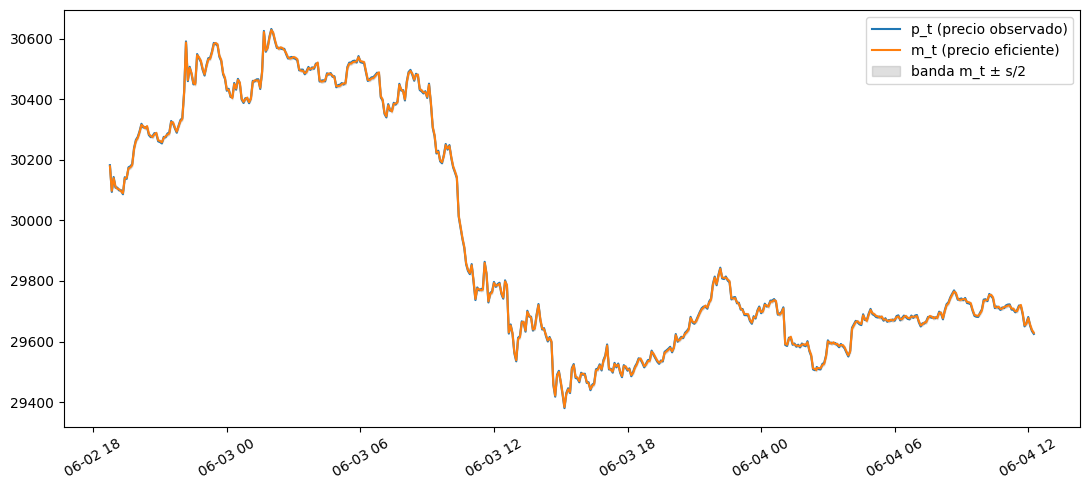

In [8]:
fig, ax = plt.subplots(figsize=(11,5))
ax.plot(seg["Datetime"], p, label="p_t (precio observado)")
ax.plot(seg["Datetime"], m, label="m_t (precio eficiente)")
ax.fill_between(seg["Datetime"], m - s/2, m + s/2, color="gray", alpha=0.25, label="banda m_t ± s/2")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()